<a href="https://colab.research.google.com/github/Salahberra2022/deep-unfolding/blob/main/RIS_MIMO_DDPG_fig7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Code source: https://github.com/baturaysaglam/RIS-MISO-Deep-Reinforcement-Learning/tree/main

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import scipy

# Plot colours
BLACK = 'k'
GREEN = '#2ca02c'
BLUE = '#1f77b4'
RED = '#d62728'
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'
TURQUOIS = '#17becf'

# Neural Netwok

In [ ]:
# Implementation of the Deep Deterministic Policy Gradient algorithm (DDPG)
# Paper: https://arxiv.org/abs/1509.02971

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, M, N, K, power_t, device, max_action=1):
        super(Actor, self).__init__()
        hidden_dim = 1 if state_dim == 0 else 2 ** (state_dim - 1).bit_length()

        self.device = device

        self.M = M
        self.N = N
        self.K = K
        self.power_t = power_t

        self.l1 = nn.Linear(state_dim, hidden_dim)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.l3 = nn.Linear(hidden_dim, action_dim)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.max_action = max_action

    def compute_power(self, a):
        # Normalize the power
        G_real = a[:, :self.M ** 2].cpu().data.numpy()
        G_imag = a[:, self.M ** 2:2 * self.M ** 2].cpu().data.numpy()

        G = G_real.reshape(G_real.shape[0], self.M, self.K) + 1j * G_imag.reshape(G_imag.shape[0], self.M, self.K)

        GG_H = np.matmul(G, np.transpose(G.conj(), (0, 2, 1)))

        current_power_t = torch.sqrt(torch.from_numpy(np.real(np.trace(GG_H, axis1=1, axis2=2)))).reshape(-1, 1).to(self.device)

        return current_power_t

    def compute_phase(self, a):
        # Normalize the phase matrix
        Phi_real = a[:, -2 * self.N:-self.N].detach()
        Phi_imag = a[:, -self.N:].detach()

        return torch.sum(torch.abs(Phi_real), dim=1).reshape(-1, 1) * np.sqrt(2), torch.sum(torch.abs(Phi_imag), dim=1).reshape(-1, 1) * np.sqrt(2)

    def forward(self, state):
        a = torch.tanh(self.l1(state.float()))

        # Apply batch normalization to the each hidden layer's input
        a = self.bn1(a)
        a = torch.tanh(self.l2(a))

        a = self.bn2(a)
        a = torch.tanh(self.l3(a))

        # Normalize the transmission power and phase matrix
        current_power_t = self.compute_power(a.detach()).expand(-1, 2 * self.M ** 2) / np.sqrt(self.power_t)

        real_normal, imag_normal = self.compute_phase(a.detach())

        real_normal = real_normal.expand(-1, self.N)
        imag_normal = imag_normal.expand(-1, self.N)

        division_term = torch.cat([current_power_t, real_normal, imag_normal], dim=1)

        return self.max_action * a / division_term


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        hidden_dim = 1 if (state_dim + action_dim) == 0 else 2 ** ((state_dim + action_dim) - 1).bit_length()

        self.l1 = nn.Linear(state_dim, hidden_dim)
        self.l2 = nn.Linear(hidden_dim + action_dim, hidden_dim)
        self.l3 = nn.Linear(hidden_dim, 1)

        self.bn1 = nn.BatchNorm1d(hidden_dim)

    def forward(self, state, action):
        q = torch.tanh(self.l1(state.float()))

        q = self.bn1(q)
        q = torch.tanh(self.l2(torch.cat([q, action], 1)))

        q = self.l3(q)

        return q


class DDPG(object):
    def __init__(self, state_dim, action_dim, M, N, K, power_t, max_action, actor_lr, critic_lr, actor_decay, critic_decay, device, discount=0.99, tau=0.001):
        self.device = device

        powert_t_W = 10 ** (power_t / 10)

        # Initialize actor networks and optimizer
        self.actor = Actor(state_dim, action_dim, M, N, K, powert_t_W, max_action=max_action, device=device).to(self.device)
        self.actor_target = copy.deepcopy(self.actor)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr, weight_decay=actor_decay)

        # Initialize critic networks and optimizer
        self.critic = Critic(state_dim, action_dim).to(self.device)
        self.critic_target = copy.deepcopy(self.critic)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr, weight_decay=critic_decay)

        # Initialize the discount and target update rated
        self.discount = discount
        self.tau = tau

    def select_action(self, state):
        self.actor.eval()

        state = torch.FloatTensor(state.reshape(1, -1)).to(self.device)
        action = self.actor(state).cpu().data.numpy().flatten().reshape(1, -1)

        return action

    def update_parameters(self, replay_buffer, batch_size=16):
        self.actor.train()

        # Sample from the experience replay buffer
        state, action, next_state, reward, not_done = replay_buffer.sample(batch_size)

        # Compute the target Q-value
        target_Q = self.critic_target(next_state, self.actor_target(next_state))
        target_Q = reward + (not_done * self.discount * target_Q).detach()

        # Get the current Q-value estimate
        current_Q = self.critic(state, action)

        # Compute the critic loss
        critic_loss = F.mse_loss(current_Q, target_Q)

        # Optimize the critic
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Compute the actor loss
        actor_loss = -self.critic(state, self.actor(state)).mean()

        # Optimize the actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Soft update the target networks
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

    # Save the model parameters
    def save(self, file_name):
        torch.save(self.critic.state_dict(), file_name + "_critic")
        torch.save(self.critic_optimizer.state_dict(), file_name + "_critic_optimizer")

        torch.save(self.actor.state_dict(), file_name + "_actor")
        torch.save(self.actor_optimizer.state_dict(), file_name + "_actor_optimizer")

    # Load the model parameters
    def load(self, file_name):
        self.critic.load_state_dict(torch.load(file_name + "_critic"))
        self.critic_optimizer.load_state_dict(torch.load(file_name + "_critic_optimizer"))
        self.critic_target = copy.deepcopy(self.critic)

        self.actor.load_state_dict(torch.load(file_name + "_actor"))
        self.actor_optimizer.load_state_dict(torch.load(file_name + "_actor_optimizer"))
        self.actor_target = copy.deepcopy(self.actor)

In [ ]:
class ExperienceReplayBuffer(object):
    def __init__(self, state_dim, action_dim, max_size=int(1e6)):
        self.max_size = max_size
        self.ptr = 0
        self.size = 0

        self.state = np.zeros((max_size, state_dim))
        self.action = np.zeros((max_size, action_dim))
        self.next_state = np.zeros((max_size, state_dim))
        self.reward = np.zeros((max_size, 1))
        self.not_done = np.zeros((max_size, 1))

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def add(self, state, action, next_state, reward, done):
        self.state[self.ptr] = state
        self.action[self.ptr] = action
        self.next_state[self.ptr] = next_state
        self.reward[self.ptr] = reward
        self.not_done[self.ptr] = 1. - done

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        index = np.random.randint(0, self.size, size=batch_size)

        return (
            torch.FloatTensor(self.state[index]).to(self.device),
            torch.FloatTensor(self.action[index]).to(self.device),
            torch.FloatTensor(self.next_state[index]).to(self.device),
            torch.FloatTensor(self.reward[index]).to(self.device),
            torch.FloatTensor(self.not_done[index]).to(self.device)
        )

# RIS_MISO

In [ ]:
class RIS_MISO(object):
    def __init__(self,
                 num_antennas,
                 num_RIS_elements,
                 num_users,
                 channel_est_error=False,
                 AWGN_var=1e-2,
                 channel_noise_var=1e-2):

        self.M = num_antennas
        self.L = num_RIS_elements
        self.K = num_users

        self.channel_est_error = channel_est_error

        assert self.M == self.K

        self.awgn_var = AWGN_var
        self.channel_noise_var = channel_noise_var

        power_size = 2 * self.K

        channel_size = 2 * (self.L * self.M + self.L * self.K)

        self.action_dim = 2 * self.M * self.K + 2 * self.L
        self.state_dim = power_size + channel_size + self.action_dim

        self.H_1 = None
        self.H_2 = None
        self.G = np.eye(self.M, dtype=complex)
        self.Phi = np.eye(self.L, dtype=complex)

        self.state = None
        self.done = None

        self.episode_t = None

    def _compute_H_2_tilde(self):
        return self.H_2.T @ self.Phi @ self.H_1 @ self.G

    def reset(self):
        self.episode_t = 0

        self.H_1 = np.random.normal(0, np.sqrt(0.5), (self.L, self.M)) + 1j * np.random.normal(0, np.sqrt(0.5),
                                                                                               (self.L, self.M))
        self.H_2 = np.random.normal(0, np.sqrt(0.5), (self.L, self.K)) + 1j * np.random.normal(0, np.sqrt(0.5),
                                                                                               (self.L, self.K))

        init_action_G = np.hstack((np.real(self.G.reshape(1, -1)), np.imag(self.G.reshape(1, -1))))
        init_action_Phi = np.hstack(
            (np.real(np.diag(self.Phi)).reshape(1, -1), np.imag(np.diag(self.Phi)).reshape(1, -1)))

        init_action = np.hstack((init_action_G, init_action_Phi))

        Phi_real = init_action[:, -2 * self.L:-self.L]
        Phi_imag = init_action[:, -self.L:]

        self.Phi = np.eye(self.L, dtype=complex) * (Phi_real + 1j * Phi_imag)

        power_t = np.real(np.diag(self.G.conjugate().T @ self.G)).reshape(1, -1) ** 2

        H_2_tilde = self._compute_H_2_tilde()
        power_r = np.linalg.norm(H_2_tilde, axis=0).reshape(1, -1) ** 2

        H_1_real, H_1_imag = np.real(self.H_1).reshape(1, -1), np.imag(self.H_1).reshape(1, -1)
        H_2_real, H_2_imag = np.real(self.H_2).reshape(1, -1), np.imag(self.H_2).reshape(1, -1)

        self.state = np.hstack((init_action, power_t, power_r, H_1_real, H_1_imag, H_2_real, H_2_imag))

        return self.state

    def _compute_reward(self, Phi):
        reward = 0
        opt_reward = 0

        for k in range(self.K):
            h_2_k = self.H_2[:, k].reshape(-1, 1)
            g_k = self.G[:, k].reshape(-1, 1)

            x = np.abs(h_2_k.T @ Phi @ self.H_1 @ g_k) ** 2

            x = x.item()

            G_removed = np.delete(self.G, k, axis=1)

            interference = np.sum(np.abs(h_2_k.T @ Phi @ self.H_1 @ G_removed) ** 2)
            y = interference + (self.K - 1) * self.awgn_var

            rho_k = x / y

            reward += np.log(1 + rho_k) / np.log(2)
            opt_reward += np.log(1 + x / ((self.K - 1) * self.awgn_var)) / np.log(2)

        return reward, opt_reward

    def step(self, action):
        self.episode_t += 1

        action = action.reshape(1, -1)

        G_real = action[:, :self.M ** 2]
        G_imag = action[:, self.M ** 2:2 * self.M ** 2]

        Phi_real = action[:, -2 * self.L:-self.L]
        Phi_imag = action[:, -self.L:]

        self.G = G_real.reshape(self.M, self.K) + 1j * G_imag.reshape(self.M, self.K)

        self.Phi = np.eye(self.L, dtype=complex) * (Phi_real + 1j * Phi_imag)

        power_t = np.real(np.diag(self.G.conjugate().T @ self.G)).reshape(1, -1) ** 2

        H_2_tilde = self._compute_H_2_tilde()

        power_r = np.linalg.norm(H_2_tilde, axis=0).reshape(1, -1) ** 2

        H_1_real, H_1_imag = np.real(self.H_1).reshape(1, -1), np.imag(self.H_1).reshape(1, -1)
        H_2_real, H_2_imag = np.real(self.H_2).reshape(1, -1), np.imag(self.H_2).reshape(1, -1)

        self.state = np.hstack((action, power_t, power_r, H_1_real, H_1_imag, H_2_real, H_2_imag))

        reward, opt_reward = self._compute_reward(self.Phi)

        done = opt_reward == reward

        return self.state, reward, done, None

    def close(self):
        pass

# Configure and Run Section

In [51]:
def whiten(state):
    return (state - np.mean(state)) / np.std(state)

# Choose the type of the experiment
experiment_type ='power'   #choices=['custom', 'power', 'rsi_elements', 'learning_rate', 'decay']
# Training-specific parameters
policy ="DDPG"
env = "RIS_MISO"
seed =0
gpu  ="0"
start_time_steps =0
buffer_size =100000
batch_size =16
save_model = "store_true"
load_model =""

# Environment-specific parameters
num_antennas =8
num_RIS_elements =8
num_users =8
power_t =10
num_time_steps_per_eps =5000
num_eps =4
awgn_var =1e-2
channel_est_error =False

# Algorithm-specific parameters
exploration_noise =0.0
discount =0.99
tau =1e-3
lr =1e-3
decay =1e-5

# Whenever you need to create a string that dynamically includes variables or computations, f-strings are a great choice due to their simplicity and readability.

file_name =f"{power_t}"     #f"{num_antennas}_{num_RIS_elements}_{num_users}_{power_t}_{lr}_{decay}"

if not os.path.exists(f"/content/drive/MyDrive/RL/Learning Curves/{experiment_type}"):
   os.makedirs(f"/content/drive/MyDrive/RL/Learning Curves/{experiment_type}")

if save_model and not os.path.exists("/content/drive/MyDrive/RL/Models"):
   os.makedirs("/content/drive/MyDrive/RL/Models")

env = RIS_MISO(num_antennas, num_RIS_elements, num_users, AWGN_var=awgn_var)

# Set seeds
torch.manual_seed(seed)
np.random.seed(seed)

state_dim = env.state_dim
action_dim = env.action_dim
max_action = 1

device = torch.device(f"cuda:{gpu}" if torch.cuda.is_available() else "cpu")
kwargs = {
        "state_dim": state_dim, "action_dim": action_dim, "power_t": power_t, "max_action": max_action,
        "M": num_antennas, "N": num_RIS_elements, "K": num_users, "actor_lr": lr, "critic_lr": lr,
        "actor_decay": decay, "critic_decay": decay, "device": device, "discount": discount, "tau": tau}

# Initialize the algorithm
agent = DDPG(**kwargs)

if load_model != "":
    policy_file = file_name if load_model == "default" else load_model
    agent.load(f"/content/drive/MyDrive/RL/Models/{policy_file}")

replay_buffer = ExperienceReplayBuffer(state_dim, action_dim, max_size=buffer_size)

# Initialize the instant rewards recording array
instant_rewards = []

max_reward = 0

for eps in range(int(num_eps)):
    state, done = env.reset(), False
    episode_reward = 0
    episode_num = 0
    episode_time_steps = 0

    state = whiten(state)

    eps_rewards = []

    for t in range(int(num_time_steps_per_eps)):
        # Choose action from the policy
        action = agent.select_action(np.array(state))

        # Take the selected action
        next_state, reward, done, _ = env.step(action)


        done = 1.0 if t == num_time_steps_per_eps - 1 else float(done)

        # Store data in the experience replay buffer
        replay_buffer.add(state, action, next_state, reward, done)

        state = next_state
        episode_reward += reward

        state = whiten(state)

        if reward > max_reward:
            max_reward = reward

        # Train the agent
        agent.update_parameters(replay_buffer, batch_size)

        #print(f"Time step: {t + 1} Episode Num: {episode_num + 1} Reward: {reward:.3f}")

        eps_rewards.append(reward)

        episode_time_steps += 1

        if done:
            print(f"\nTotal T: {t + 1} Episode Num: {episode_num + 1} Episode T: {episode_time_steps} Max. Reward: {max_reward:.3f}\n")

            # Reset the environment
            state, done = env.reset(), False
            episode_reward = 0
            episode_time_steps = 0
            episode_num += 1

            state = whiten(state)

            instant_rewards.append(eps_rewards)

            np.save(f"/content/drive/MyDrive/RL/Learning Curves/{experiment_type}/{file_name}",instant_rewards)  #_episode_{episode_num + 1}
            csv_file_path = f"/content/drive/MyDrive/RL/Learning Curves/{experiment_type}/{file_name}.csv"
            np.savetxt(csv_file_path,instant_rewards, delimiter=",", header="Instant Rewards", comments="")

if save_model:
    agent.save(f"/content/drive/MyDrive/RL/Models/{file_name}")


Total T: 5000 Episode Num: 1 Episode T: 5000 Max. Reward: 3.464


Total T: 5000 Episode Num: 1 Episode T: 5000 Max. Reward: 3.464


Total T: 5000 Episode Num: 1 Episode T: 5000 Max. Reward: 3.464


Total T: 5000 Episode Num: 1 Episode T: 5000 Max. Reward: 3.464



# Plot section

**For plotting the figure 7**

In [60]:
def compute_avg_reward(reward):
    avg_reward = np.zeros(num_time_steps_per_eps)
    #print(avg_reward.shape)
    #print(range(len(reward)))
    #print(reward[:(1)])
    for i in range(num_time_steps_per_eps):
        avg_reward[i] = np.sum(reward[:,i]) / num_eps

    return avg_reward


# results for figure 7
def get_results(figure_num, results_dir):
    x_ticks = [0, 1000, 2000, 3000, 4000, 5000]
    x_tick_vals = x_ticks

    y_ticks = None
    marker = None

    x_label = "Steps"
    y_label = "Average rewards"

    results = []
    legend = []

    fig_dir = f"{results_dir}/power"

    #power_levels = [-10,0,10,20,30]
    power_levels = [10]

    for p_t in power_levels:
        reward = np.load(f"{fig_dir}/{p_t}.npy").squeeze()
        #print(reward)
        #print(reward.shape)
        avg_reward = compute_avg_reward(reward)
        results.append(avg_reward)

        legend.append(f"$P_t$ = {p_t}dB")

    legend_loc = 'best'
    colors = [RED, BLUE, TURQUOIS, PURPLE, BLACK]

    y_ticks = [1, 2, 3, 4, 5, 6, 7, 8]
    result1 = np.array(results)
    print(result1.shape)


    save_name = f"{figure_num}_reproduced.jpg"

    return results, legend, legend_loc, colors, x_ticks, x_tick_vals, y_ticks, marker, x_label, y_label, save_name




(1, 5000)


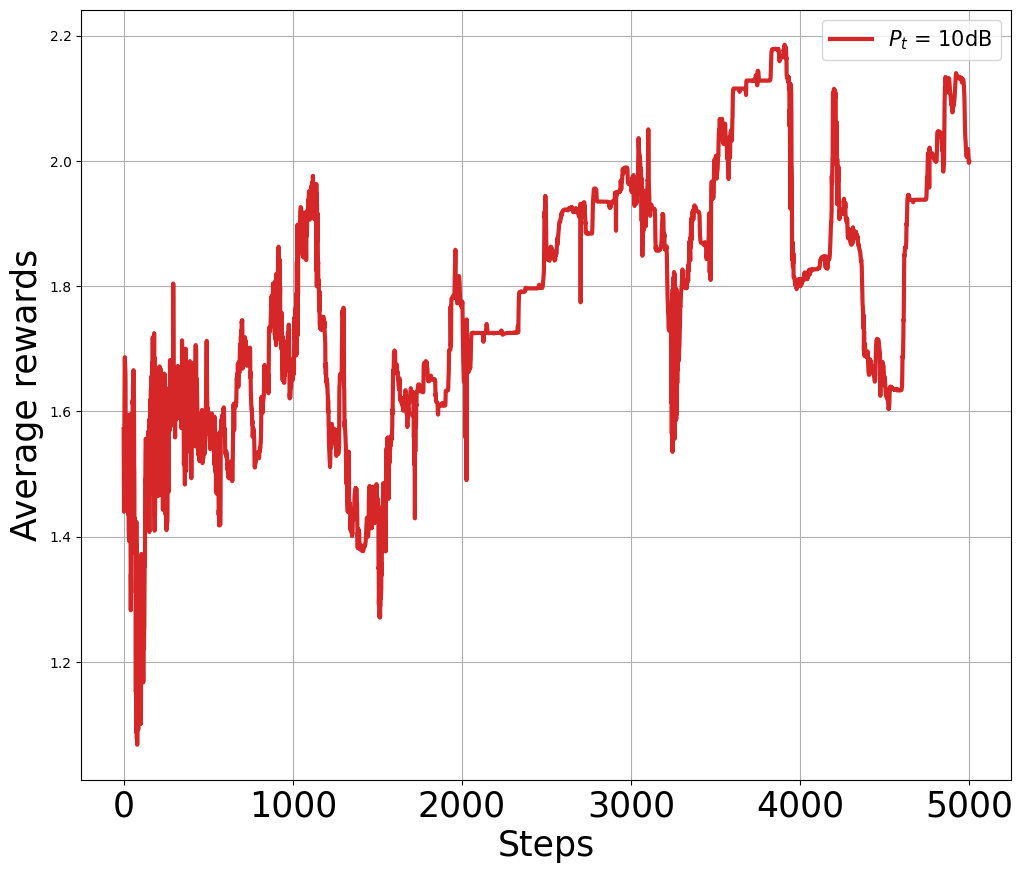

In [61]:
# Choose the type of the experiment
figure_num = 7 # choices=[4, 5, 6, 7, 8, 9, 10, 11, 12],  help='Choose one of figures from the paper to reproduce'

results_dir = "/content/drive/MyDrive/RL/Learning Curves"
fig_dir = f"/content/drive/MyDrive/RL/Learning Figures"

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)

results, legend, legend_loc, colors, x_ticks, x_tick_vals, y_ticks, markers, x_label, y_label, save_name = get_results(figure_num, results_dir)
#print(results)
plt.rcParams['figure.figsize'] = [12, 10]

linewidth = 3
legend_size = 30

font_size =  25
legend_font_size = 15


for res, color in zip(results, colors):
    plt.plot(res, linewidth=linewidth, color=color)


y_ticks_vals = y_ticks

plt.xticks(x_tick_vals, x_ticks, fontsize=font_size)

plt.xlabel(x_label, fontsize=font_size)
plt.ylabel(y_label, fontsize=font_size)

plt.legend(legend, loc=legend_loc, fontsize=legend_font_size, ncol=1)

plt.grid(True)

plt.savefig(f"{fig_dir}/{save_name}", bbox_inches='tight')
plt.show()